<a href="https://colab.research.google.com/github/nannastahl/CB2330-project/blob/main/F%C3%B6rslag_kod_number_of_contacts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Observed contacts: 36
Simulated contacts: 34
Acceptance rate: 0.3329


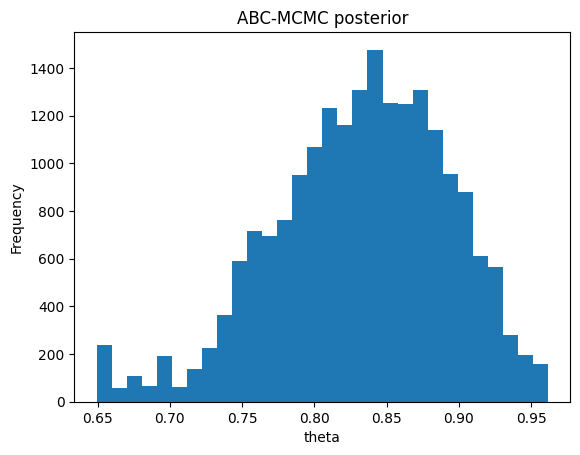

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_RESIDUES = 42
x_obs = 36 #36 of 42 amino acids in contact with DOPS membrane at pH 7

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

seed = 30


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def simulation(theta, seed, n_residues=42):
    state = seed
    contacts = 0

    for i in range(n_residues):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        rs = state / M_LCG #Random number between 0 and 1

        if rs < theta: #Amino acid is in contact with membrane
            contacts += 1

    return contacts, state
x_sim, state = simulation(theta=0.85, seed=30)

print("Observed contacts:", x_obs)
print("Simulated contacts:", x_sim)


def summary(x):
    return x

PRIOR = (0.0, 1.0)

def abc_mcmc(n_steps, epsilon, start, state, half_width=0.03):

    theta = start
    chain = [0.0] * n_steps
    n_acc = 0

    for t in range(n_steps):

        #Propose new theta close to current theta
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        prop = theta + half_width * (2 * state / M_LCG - 1)

        #Only use theta values inside prior
        if PRIOR[0] <= prop <= PRIOR[1]:

            x_sim, state = simulation(prop, state)

            #Accept if simulated number of contacts is close enough to observed
            if abs(summary(x_sim) - summary(x_obs)) <= epsilon:
                theta = prop
                n_acc += 1

        chain[t] = theta

    return chain, n_acc, state

chain, n_acc, state = abc_mcmc(n_steps=20000, epsilon=1, start=0.85, state=seed)

print("Acceptance rate:", n_acc / len(chain))

posterior = chain
plt.hist(posterior, bins=30)
plt.xlabel("theta")
plt.ylabel("Frequency")
plt.title("ABC-MCMC posterior")
plt.show()